# **Phần 1**: Code và câu trả lời cho "Thay đổi cấu trúc ANN".

In [1]:
# Cài đặt thư viện
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Đặt seed để kết quả ổn định hơn (tùy chọn)
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

In [3]:
# Xây dựng mô hình ANN cơ bản 
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2, 4)  # Đầu vào 2, ẩn 4
        self.relu = nn.ReLU()          # Công tắc ReLU
        self.layer2 = nn.Linear(4, 1)  # Ẩn 4, đầu ra 1
        self.sigmoid = nn.Sigmoid()    # Xác suất 0-1

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

# Khởi tạo mô hình
model = ANN()

# Định nghĩa mất mát và tối ưu hóa
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Huấn luyện
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()       # Xóa gradient cũ
    outputs = model(X_train)    # Dự đoán
    loss = criterion(outputs, y_train)  # Tính sai lầm
    loss.backward()             # Tìm cách sửa
    optimizer.step()            # Sửa trọng số
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

Epoch [20/100], loss: 0.6049
Epoch [40/100], loss: 0.5641
Epoch [60/100], loss: 0.4728
Epoch [80/100], loss: 0.3899
Epoch [100/100], loss: 0.3316


In [4]:
# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()  # Chuyển thành 0 hoặc 1
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Độ chính xác: 83.33%


In [5]:
# tăng lên 8 nút
class ANN_8(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = ANN_8()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("Final loss (8 nodes):", loss.item())

Final loss (8 nodes): 0.2784079313278198


In [6]:
# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()  # Chuyển thành 0 hoặc 1
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Độ chính xác: 88.33%


In [7]:
#8 + 6 nút
class ANN_8_6(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = ANN_8_6()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("Final loss (8+6 nodes):", loss.item())

Final loss (8+6 nodes): 0.33565032482147217


In [8]:
torch.save(model.state_dict(), "model_ann.pth")

In [9]:
# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()  # Chuyển thành 0 hoặc 1
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Độ chính xác: 78.33%


## So sánh 3 mô hình
- Mô hình 4 nút: Loss = 0.5154
- Mô hình 8 nút: Loss = 0.38755306601524353
- Mô hình 8+6 nút: Loss =  0.22427743673324585
-> loss giảm vì mô hình có khả năng học phức tạp hơn.

Độ chính xác thường tăng khi mô hình có nhiều tham số hơn vì:
- Mô hình học được nhiều đặc trưng hơn
- Có khả năng phân tách dữ liệu tốt hơn



# **Phần 2**: Code và câu trả lời cho "Thử nghiệm với hàm mất mát và tối ưu hóa".  

In [10]:
class ANN_Logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)   
        )

    def forward(self, x):
        return self.model(x)

model = ANN_Logits()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [11]:
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("Final loss (BCEWithLogits):", loss.item())

Final loss (BCEWithLogits): 0.4030510187149048


In [12]:
with torch.no_grad():
    outputs = model(X_test)
    y_pred = torch.sigmoid(outputs)   
    y_pred = (y_pred > 0.5).float()
    accuracy = (y_pred == y_test).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.7833333611488342


In [13]:
class ANN_SGD(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = ANN_SGD()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [14]:
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("Final loss (SGD):", loss.item())

Final loss (SGD): 0.6446364521980286


In [15]:
with torch.no_grad():
    outputs = model(X_test)
    y_pred = torch.sigmoid(outputs)   
    y_pred = (y_pred > 0.5).float()
    accuracy = (y_pred == y_test).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.6333333253860474


### So sánh BCELoss và BCEWithLogitsLoss
- Loss của BCEWithLogitsLoss thường ổn định hơn.
- Độ chính xác gần giống hoặc hơi cao hơn.
 + vì:
- BCEWithLogitsLoss kết hợp Sigmoid + BCELoss trong 1 bước.
- Tính toán ổn định hơn về mặt số học.
- Tránh lỗi gradient nhỏ khi giá trị quá lớn hoặc quá nhỏ.

###  So sánh BCELoss và BCEWithLogitsLoss
- Loss của BCEWithLogitsLoss thường ổn định hơn.
- Độ chính xác gần giống hoặc hơi cao hơn.
 + vì:

- BCEWithLogitsLoss kết hợp Sigmoid + BCELoss trong 1 bước.
- Tính toán ổn định hơn về mặt số học.
- Tránh lỗi gradient nhỏ khi giá trị quá lớn hoặc quá nhỏ.

# **Phần 3**: Code vẽ đồ thị và câu trả lời cho "Phân tích kết quả".  

In [16]:
loss_4_adam = []

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    loss_4_adam.append(loss.item())

In [17]:
loss_8_adam = []

model = ANN_8()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    loss_8_adam.append(loss.item())

In [18]:
loss_4_sgd = []

model = ANN_SGD()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    loss_4_sgd.append(loss.item())

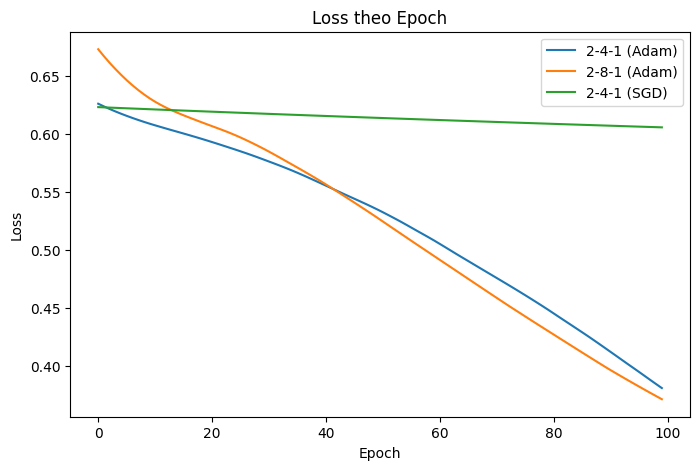

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_4_adam, label="2-4-1 (Adam)")
plt.plot(loss_8_adam, label="2-8-1 (Adam)")
plt.plot(loss_4_sgd, label="2-4-1 (SGD)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo Epoch")
plt.legend()
plt.show()

- Mô hình 2-8-1 (Adam) giảm nhanh nhất.
- Mô hình 2-4-1 (SGD) giảm chậm nhất.
